# e3vote Benchmark Visualizations

Generates publication-quality figures from `votes.csv` and `results.json` output.

**Reviewer requirements addressed:**
- M5: Statistical rigor (confidence intervals, error bars)
- M5: Scale-up analysis (TPS vs voter count)
- M5: End-to-end timing decomposition
- M5: Separate ZKP/encryption timing
- M4: Tally gas scalability (max ballots per tx)
- M5: Blockchain performance (TPS, gas utilization, inclusion delay)

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'figure.figsize': (7, 4),
    'figure.dpi': 150,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# --- CONFIGURE PATHS ---
RUN_DIR = Path('benchmarks/run_20260509_163259')  # Update to your run
CSV_PATH = RUN_DIR / 'votes.csv'
JSON_PATH = RUN_DIR / 'results.json'

df = pd.read_csv(CSV_PATH)
with open(JSON_PATH) as f:
    results = json.load(f)

print(f"Loaded {len(df)} vote records across scale points: {df['scale_point'].unique()}")
df.head()

Loaded 9000 vote records across scale points: [ 100  200  500 1000]


,scale_point,repetition,vote_id,voter_address,encrypt_time_ms,grant_time_ms,inclusion_delay_ms,casting_time_ms,gas_used,block_number,status,error_phase,error_message
0,100,0,0,0xC0B835CAa3c60df8B396691246562ec6ef1b75d4,1.903294,6331.677737,5594,8480.077379,1167598,245,success,NaN,NaN
1,100,0,1,0x2e9de0fec4ccab5c433e6aD179756477A7099Ef0,1.853475,6278.035276,5593,8473.795576,1167610,245,success,NaN,NaN
2,100,0,2,0x5Ab830759509361850DDed1e58Dc907f5F012115,1.862180,6328.281637,5593,8509.787906,1167718,245,success,NaN,NaN
3,100,0,3,0x39f308da9c88F95DEbc9b62F393d1BA04476A4F1,1.841145,6348.521120,5593,8513.739227,1167670,245,success,NaN,NaN
4,100,0,4,0x74A64b5e251274e239dDF7400c8C3b8aC76C3a4f,1.925158,6411.732324,5593,7572.965182,1167718,245,success,NaN,NaN


## 1. Throughput (TPS) vs Scale Point
Shows how the system's confirmed transaction rate changes with voter count. Error bars show 95% CI across repetitions.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


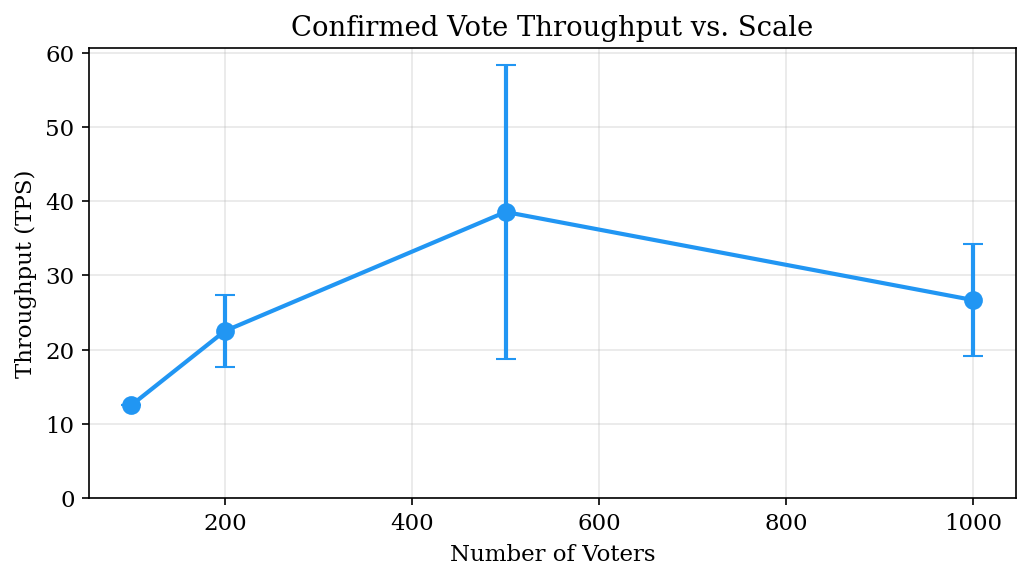

In [12]:
tps_data = []
for sp in results['scalePoints']:
    voters = sp['voters']
    agg = sp.get('aggregated', {}).get('tps', {})
    if agg:
        tps_data.append({'voters': voters, 'mean': agg['mean'], 'ci95': agg['ci95']})

if tps_data:
    tps_df = pd.DataFrame(tps_data)
    fig, ax = plt.subplots()
    ax.errorbar(tps_df['voters'], tps_df['mean'], yerr=tps_df['ci95'],
                fmt='o-', capsize=5, color='#2196F3', linewidth=2, markersize=8)
    ax.set_xlabel('Number of Voters')
    ax.set_ylabel('Throughput (TPS)')
    ax.set_title('Confirmed Vote Throughput vs. Scale')
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.savefig(RUN_DIR / 'fig_tps_vs_scale.eps', format='eps')
    plt.show()
else:
    print('Not enough scale points for TPS plot (need multiple scale points with repetitions)')

## 2. End-to-End Timing Decomposition
Stacked bar chart showing where time is spent: encryption, grant, on-chain inclusion. Addresses M5 requirement for separated timing.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


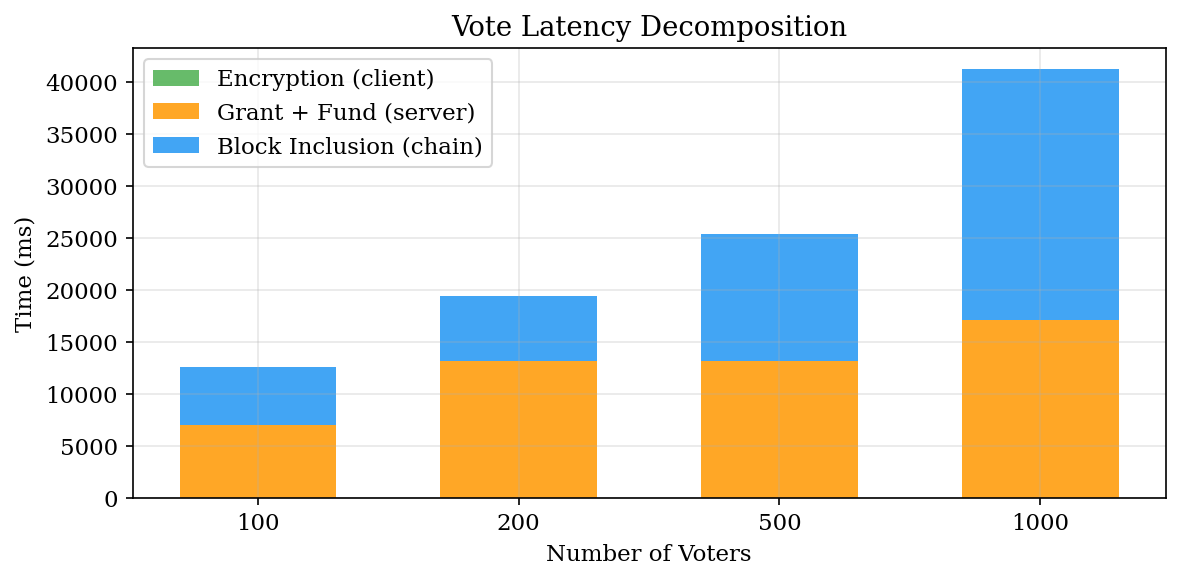

In [13]:
successful = df[df['status'] == 'success'].copy()

timing_cols = ['encrypt_time_ms', 'grant_time_ms', 'inclusion_delay_ms']
labels = ['Encryption (client)', 'Grant + Fund (server)', 'Block Inclusion (chain)']
colors = ['#4CAF50', '#FF9800', '#2196F3']

if not successful.empty:
    means = [successful[c].mean() for c in timing_cols]
    
    fig, ax = plt.subplots(figsize=(8, 4))
    
    # Per scale point if multiple
    scale_points = sorted(successful['scale_point'].unique())
    x = np.arange(len(scale_points))
    width = 0.6
    
    bottoms = np.zeros(len(scale_points))
    for col, label, color in zip(timing_cols, labels, colors):
        vals = [successful[successful['scale_point'] == sp][col].mean() for sp in scale_points]
        ax.bar(x, vals, width, bottom=bottoms, label=label, color=color, alpha=0.85)
        bottoms += np.array(vals)
    
    ax.set_xlabel('Number of Voters')
    ax.set_ylabel('Time (ms)')
    ax.set_title('Vote Latency Decomposition')
    ax.set_xticks(x)
    ax.set_xticklabels(scale_points)
    ax.legend(loc='upper left')
    plt.tight_layout()
    plt.savefig(RUN_DIR / 'fig_timing_decomposition.eps', format='eps')
    plt.show()

## 3. Casting Time Distribution
Box plot of end-to-end casting time per scale point. Shows variance and outliers.

/tmp/ipykernel_10377/254163049.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=scale_points, patch_artist=True)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


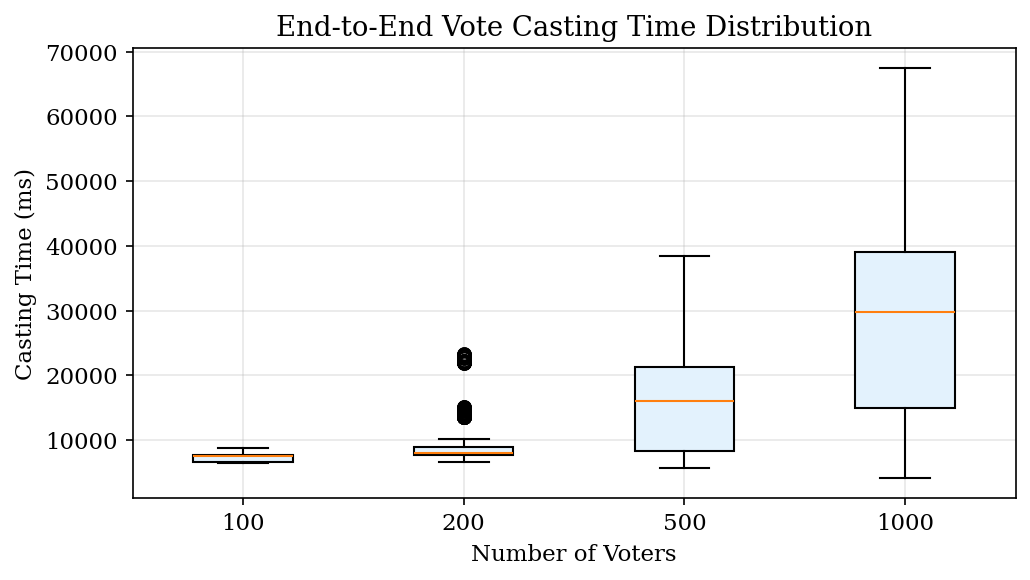

In [14]:
if not successful.empty:
    fig, ax = plt.subplots()
    scale_points = sorted(successful['scale_point'].unique())
    data = [successful[successful['scale_point'] == sp]['casting_time_ms'].dropna() for sp in scale_points]
    
    bp = ax.boxplot(data, labels=scale_points, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('#E3F2FD')
    
    ax.set_xlabel('Number of Voters')
    ax.set_ylabel('Casting Time (ms)')
    ax.set_title('End-to-End Vote Casting Time Distribution')
    plt.tight_layout()
    plt.savefig(RUN_DIR / 'fig_casting_time_boxplot.eps', format='eps')
    plt.show()

## 4. Inclusion Delay Distribution
How long voters wait for their vote to be included in a block. Critical UX metric.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


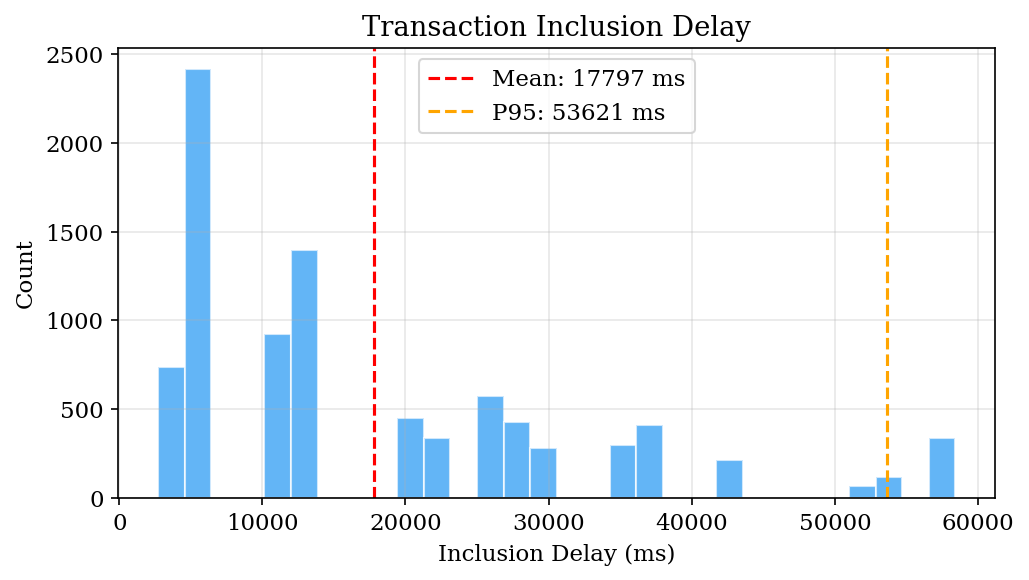

In [15]:
if not successful.empty and 'inclusion_delay_ms' in successful.columns:
    fig, ax = plt.subplots()
    delays = successful['inclusion_delay_ms'].dropna()
    ax.hist(delays, bins=30, color='#2196F3', alpha=0.7, edgecolor='white')
    ax.axvline(delays.mean(), color='red', linestyle='--', label=f'Mean: {delays.mean():.0f} ms')
    ax.axvline(delays.quantile(0.95), color='orange', linestyle='--', label=f'P95: {delays.quantile(0.95):.0f} ms')
    ax.set_xlabel('Inclusion Delay (ms)')
    ax.set_ylabel('Count')
    ax.set_title('Transaction Inclusion Delay')
    ax.legend()
    plt.tight_layout()
    plt.savefig(RUN_DIR / 'fig_inclusion_delay.eps', format='eps')
    plt.show()

## 5. Gas Utilization per Block
Shows how full blocks are during the voting phase. Addresses M4 gas limit concerns.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


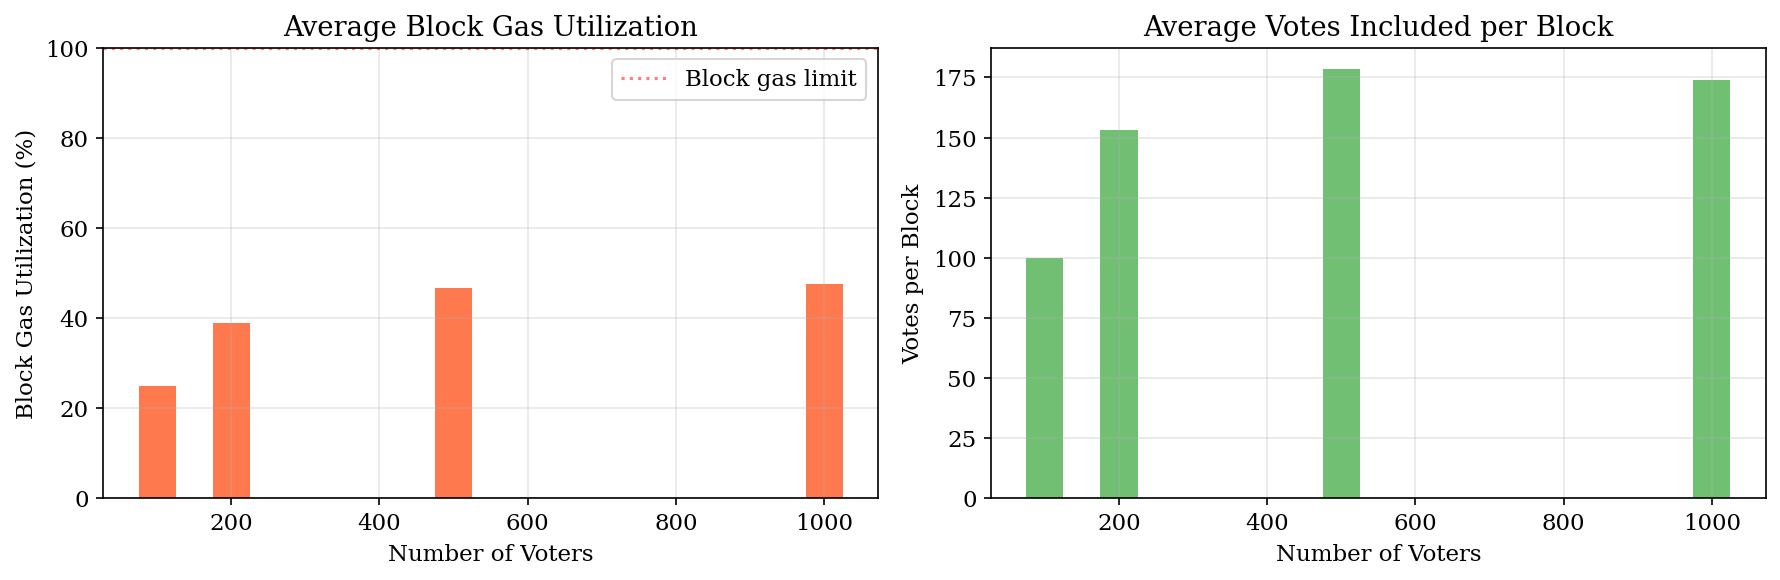

In [16]:
# Extract block data from results.json
all_blocks = []
for sp in results['scalePoints']:
    for rep in sp['repetitions']:
        throughput = rep.get('throughput')
        if throughput:
            all_blocks.append({
                'voters': sp['voters'],
                'rep': rep['rep'],
                'gasUtil': throughput['avgGasUtil'],
                'votesPerBlock': throughput['avgVotesPerBlock'],
                'tps': throughput['tps'],
            })

if all_blocks:
    blocks_df = pd.DataFrame(all_blocks)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Gas utilization
    for sp in sorted(blocks_df['voters'].unique()):
        subset = blocks_df[blocks_df['voters'] == sp]
        ax1.bar(sp, subset['gasUtil'].mean() * 100, width=50, alpha=0.8, color='#FF5722')
    ax1.set_xlabel('Number of Voters')
    ax1.set_ylabel('Block Gas Utilization (%)')
    ax1.set_title('Average Block Gas Utilization')
    ax1.set_ylim(0, 100)
    ax1.axhline(100, color='red', linestyle=':', alpha=0.5, label='Block gas limit')
    ax1.legend()
    
    # Votes per block
    for sp in sorted(blocks_df['voters'].unique()):
        subset = blocks_df[blocks_df['voters'] == sp]
        ax2.bar(sp, subset['votesPerBlock'].mean(), width=50, alpha=0.8, color='#4CAF50')
    ax2.set_xlabel('Number of Voters')
    ax2.set_ylabel('Votes per Block')
    ax2.set_title('Average Votes Included per Block')
    
    plt.tight_layout()
    plt.savefig(RUN_DIR / 'fig_gas_utilization.eps', format='eps')
    plt.show()

## 6. Tally Gas Scalability
Shows the deterministic gas model and maximum ballots per transaction. Directly addresses M4.

In [17]:
gas_model = results.get('gasModel', {})
per_ballot = gas_model.get('perBallotTallyGas', 0)
block_limit = gas_model.get('blockGasLimit', 60_000_000)
max_ballots = gas_model.get('maxBallotsPerTallyTx', 0)
per_vote_tx = gas_model.get('perVoteTxGas', 0)

if per_ballot > 0:
    # Project tally gas cost for different ballot counts
    ballot_counts = np.arange(10, max_ballots + 100, 10)
    tally_gas = per_ballot * ballot_counts
    
    fig, ax = plt.subplots()
    ax.plot(ballot_counts, tally_gas / 1e6, 'b-', linewidth=2, label='Tally gas cost')
    ax.axhline(block_limit / 1e6, color='red', linestyle='--', linewidth=2, label=f'Block gas limit ({block_limit/1e6:.0f}M)')
    ax.axvline(max_ballots, color='green', linestyle=':', linewidth=2, label=f'Max ballots = {max_ballots}')
    ax.fill_between(ballot_counts, 0, tally_gas / 1e6, alpha=0.1, color='blue')
    
    ax.set_xlabel('Number of Ballots')
    ax.set_ylabel('Gas (millions)')
    ax.set_title('Tally Gas Cost vs. Ballot Count (Deterministic Model)')
    ax.legend()
    ax.set_ylim(0, block_limit / 1e6 * 1.1)
    
    # Add annotation
    ax.annotate(f'{per_ballot:.0f} gas/ballot\nMax {max_ballots} ballots/tx',
                xy=(max_ballots, block_limit / 1e6), xytext=(max_ballots * 0.5, block_limit / 1e6 * 0.7),
                arrowprops=dict(arrowstyle='->', color='black'),
                fontsize=10, ha='center')
    
    plt.tight_layout()
    plt.savefig(RUN_DIR / 'fig_tally_gas_scalability.eps', format='eps')
    plt.show()
    
    print(f"\nGas Model Summary:")
    print(f"  Per-ballot tally gas: {per_ballot:.0f}")
    print(f"  Block gas limit: {block_limit:,}")
    print(f"  Max ballots per tally tx: {max_ballots}")
    print(f"  Per-vote transaction gas: {per_vote_tx:,}")
    print(f"  Max votes per block (voting phase): {block_limit // per_vote_tx if per_vote_tx else 'N/A'}")

## 7. Summary Table
Publication-ready table with all key metrics per scale point.

In [18]:
summary_rows = []
for sp in results['scalePoints']:
    agg = sp.get('aggregated', {})
    row = {'Voters': sp['voters']}
    
    for metric, label in [('tps', 'TPS'), ('castingTime', 'Casting (ms)'),
                           ('grantTime', 'Grant (ms)'), ('inclusionDelay', 'Inclusion (ms)')]:
        m = agg.get(metric, {})
        if m:
            row[label] = f"{m['mean']:.1f} ± {m['ci95']:.1f}"
        else:
            row[label] = '-'
    
    failures = agg.get('failures', {})
    row['Success Rate'] = f"{failures.get('successes', 0)}/{failures.get('total', 0)}"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
print(f"\nMetadata: {results['metadata']['timestamp']}, commit: {results['metadata']['gitCommit'][:8]}")

 Voters         TPS Casting (ms)      Grant (ms)   Inclusion (ms) Success Rate
    100  12.5 ± 0.0            - 7042.9 ± 1596.3   5544.6 ± 163.7      500/500
    200  22.5 ± 4.9            - 13178.9 ± 253.0  6241.5 ± 1507.0    1000/1000
    500 38.5 ± 19.8            - 13141.3 ± 527.8 12232.2 ± 2763.9    2500/2500
   1000  26.7 ± 7.6            - 17061.5 ± 835.5 24116.3 ± 7697.4    5000/5000

Metadata: 2026-05-09T16:50:59.173907, commit: 3e4d5959


## 8. Consensus Latency Analysis
Per-scale-point distribution of node consensus latency metrics:
- **Inclusion Delay**: time from transaction submission to block inclusion (block timestamp − submit time)
- **Casting Time (Round-trip)**: full latency from sendSignedTransaction to receipt confirmation

These metrics characterize the PoA consensus overhead under increasing load.

/tmp/ipykernel_10377/4077115130.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=successful, x='scale_point', y='inclusion_delay_ms',
/tmp/ipykernel_10377/4077115130.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=successful, x='scale_point', y='casting_time_ms',
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


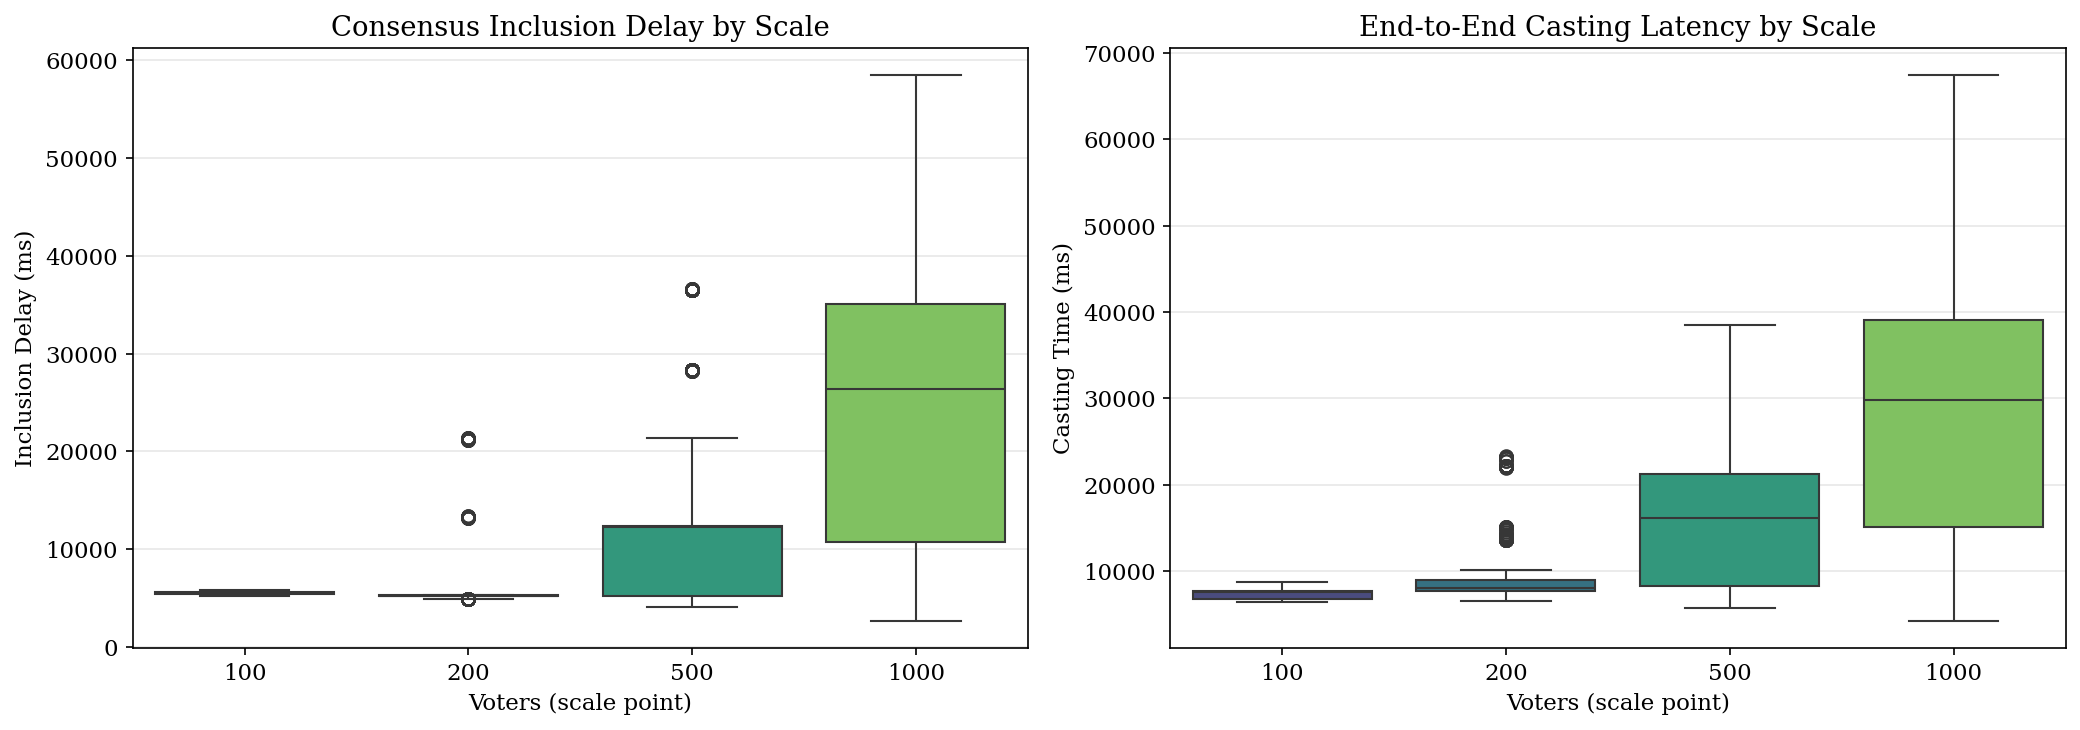

,inclusion_delay_ms_mean,inclusion_delay_ms_median,inclusion_delay_ms_std,inclusion_delay_ms_p95,casting_time_ms_mean,casting_time_ms_median,casting_time_ms_std,casting_time_ms_p95
scale_point,,,,,,,,
100,5544.6,5580.0,169.9,5809.0,7305.2,7494.3,579.6,8507.7
200,6241.5,5277.0,3664.5,13348.2,9357.0,8003.1,3501.5,15079.9
500,12232.2,12248.0,7282.7,21325.0,16178.9,16075.4,7631.8,29237.2
1000,24116.3,26388.0,15892.5,58379.0,28535.2,29825.5,15874.5,62011.1


In [19]:
if not successful.empty and 'inclusion_delay_ms' in successful.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Inclusion delay by scale point
    sns.boxplot(data=successful, x='scale_point', y='inclusion_delay_ms',
                ax=axes[0], palette='viridis')
    axes[0].set_xlabel('Voters (scale point)')
    axes[0].set_ylabel('Inclusion Delay (ms)')
    axes[0].set_title('Consensus Inclusion Delay by Scale')

    # Right: Casting time (full round-trip) by scale point
    sns.boxplot(data=successful, x='scale_point', y='casting_time_ms',
                ax=axes[1], palette='viridis')
    axes[1].set_xlabel('Voters (scale point)')
    axes[1].set_ylabel('Casting Time (ms)')
    axes[1].set_title('End-to-End Casting Latency by Scale')

    plt.tight_layout()
    plt.savefig(RUN_DIR / 'fig_consensus_latency.eps', format='eps')
    plt.savefig(RUN_DIR / 'fig_consensus_latency.png', dpi=150)
    plt.show()

    # Summary statistics table
    latency_stats = successful.groupby('scale_point')[[
        'inclusion_delay_ms', 'casting_time_ms'
    ]].agg(['mean', 'median', 'std', lambda x: x.quantile(0.95)])
    latency_stats.columns = [f'{col[0]}_{col[1]}' if col[1] != '<lambda_0>' else f'{col[0]}_p95'
                              for col in latency_stats.columns]
    display(latency_stats.round(1))
